## Setup & Installation

In [1]:
# ── Install all required packages (run at start of every session) ──
!pip install mtcnn lz4 gradio keras-facenet -q
print('All packages installed ✅')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.8 MB/s eta 0:00:00
All packages installed ✅


## Load Dataset from Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

# Only extract if not already extracted
if not os.path.exists('/content/data/mtcnn_splits/train'):
    print("Extracting dataset...")
    with zipfile.ZipFile('/content/drive/MyDrive/mtcnn_splits.zip', 'r') as z:
        z.extractall('/content')
    print("Extracted ✅")
else:
    print("Dataset already exists ✅")

# Verify
for split in ['train', 'val', 'test']:
    split_dir = f'/content/data/mtcnn_splits/{split}'
    total = sum(len(os.listdir(os.path.join(split_dir, a)))
                for a in os.listdir(split_dir))
    print(f"{split}: {total} images, {len(os.listdir(split_dir))} actors")

Mounted at /content/drive
Extracting dataset...
Extracted ✅
train: 16554 images, 100 actors
val: 3511 images, 100 actors
test: 3651 images, 100 actors


## Configuration

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

TRAIN_DIR   = '/content/data/mtcnn_splits/train'
VAL_DIR     = '/content/data/mtcnn_splits/val'
TEST_DIR    = '/content/data/mtcnn_splits/test'
SAVE_PATH   = '/content/drive/MyDrive/capstone_facerec/'
os.makedirs(SAVE_PATH, exist_ok=True)

IMG_SIZE    = (160, 160)
BATCH_SIZE  = 32
NUM_CLASSES = 100

print("TensorFlow :", tf.__version__)
print("GPU        :", tf.config.list_physical_devices('GPU'))

TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data Pipeline & Preprocessing

In [5]:
def build_dataset(directory, augment=False):
    dataset = tf.keras.utils.image_dataset_from_directory(
        directory,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        shuffle=augment,
        seed=42
    )
    def preprocess(image, label):
        image = tf.cast(image, tf.float32) / 255.0
        if augment:
            image = tf.image.random_flip_left_right(image)
            image = tf.image.random_brightness(image, 0.2)
            image = tf.image.random_contrast(image, 0.8, 1.2)
        return image, label
    return dataset.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

train_ds = build_dataset(TRAIN_DIR, augment=True)
val_ds   = build_dataset(VAL_DIR,   augment=False)
test_ds  = build_dataset(TEST_DIR,  augment=False)

print(f"Train batches : {len(train_ds)}")
print(f"Val batches   : {len(val_ds)}")
print(f"Test batches  : {len(test_ds)}")

Found 16554 files belonging to 100 classes.
Found 3511 files belonging to 100 classes.
Found 3651 files belonging to 100 classes.
Train batches : 518
Val batches   : 110
Test batches  : 115


## Baseline Model — MobileNetV2

In [6]:
def build_mobilenet(trainable_base=False, unfreeze_layers=0):
    base = MobileNetV2(input_shape=(160, 160, 3), include_top=False, weights='imagenet')
    base.trainable = False
    if trainable_base and unfreeze_layers > 0:
        for layer in base.layers[-unfreeze_layers:]:
            layer.trainable = True

    inputs  = tf.keras.Input(shape=(160, 160, 3))
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return models.Model(inputs, outputs)

mobilenet_model = build_mobilenet(trainable_base=False)
mobilenet_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_accuracy')]
)
print("MobileNetV2 ready ✅")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 ready ✅


In [ ]:
callbacks_mobilenet = [
    ModelCheckpoint(SAVE_PATH + 'mobilenet_best.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

history_mobilenet = mobilenet_model.fit(
    train_ds, epochs=10, validation_data=val_ds, callbacks=callbacks_mobilenet
)

Epoch 1/10
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.1019 - loss: 4.3929 - top5_accuracy: 0.2699
Epoch 1: val_accuracy improved from None to 0.29393, saving model to /content/drive/MyDrive/capstone_facerec/mobilenet_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/capstone_facerec/mobilenet_best.keras
518/518 ━━━━━━━━━━━━━━━━━━━━ 78s 101ms/step - accuracy: 0.1611 - loss: 3.8653 - top5_accuracy: 0.3792 - val_accuracy: 0.2939 - val_loss: 2.9644 - val_top5_accuracy: 0.5705 - learning_rate: 0.0010
Epoch 2/10
516/518 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3156 - loss: 2.8415 - top5_accuracy: 0.6042
Epoch 2: val_accuracy improved from 0.29393 to 0.35346, saving model to /content/drive/MyDrive/capstone_facerec/mobilenet_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/capstone_facerec/mobilenet_best.keras
518/518 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.3229 - loss: 2.8129 - top5_accuracy: 0.6112 - val_accuracy: 0.3535 - v

In [7]:
results_mobilenet = mobilenet_model.evaluate(test_ds, verbose=0)
print("MobileNetV2 Results:")
print(f"  Top-1 Accuracy : {results_mobilenet[1]*100:.2f}%")
print(f"  Top-5 Accuracy : {results_mobilenet[2]*100:.2f}%")

MobileNetV2 Results:
  Top-1 Accuracy : 1.01%
  Top-5 Accuracy : 5.34%


## Baseline Model — FaceNet (Frozen)

In [8]:
from keras_facenet import FaceNet

embedder      = FaceNet()
facenet_base  = embedder.model
facenet_base.trainable = False

inputs  = tf.keras.Input(shape=(160, 160, 3))
x       = facenet_base(inputs, training=False)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

facenet_model = models.Model(inputs, outputs)
facenet_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_accuracy')]
)
print('FaceNet ready ✅')

FaceNet ready ✅


In [ ]:
callbacks_facenet = [
    ModelCheckpoint(SAVE_PATH + 'facenet_best.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

history_facenet = facenet_model.fit(
    train_ds, epochs=10, validation_data=val_ds, callbacks=callbacks_facenet
)

Epoch 1/10
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.3797 - loss: 2.8832 - top5_accuracy: 0.5693
Epoch 1: val_accuracy improved from None to 0.74024, saving model to /content/drive/MyDrive/capstone_facerec/facenet_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/capstone_facerec/facenet_best.keras
518/518 ━━━━━━━━━━━━━━━━━━━━ 76s 109ms/step - accuracy: 0.5448 - loss: 2.0251 - top5_accuracy: 0.7426 - val_accuracy: 0.7402 - val_loss: 1.5774 - val_top5_accuracy: 0.8838 - learning_rate: 0.0010
Epoch 2/10
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6916 - loss: 1.2996 - top5_accuracy: 0.8613
Epoch 2: val_accuracy improved from 0.74024 to 0.74765, saving model to /content/drive/MyDrive/capstone_facerec/facenet_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/capstone_facerec/facenet_best.keras
518/518 ━━━━━━━━━━━━━━━━━━━━ 32s 62ms/step - accuracy: 0.6965 - loss: 1.2802 - top5_accuracy: 0.8625 - val_accuracy: 0.7477 - val_loss:

In [9]:
results_facenet = facenet_model.evaluate(test_ds, verbose=0)
print("FaceNet Results:")
print(f"  Top-1 Accuracy : {results_facenet[1]*100:.2f}%")
print(f"  Top-5 Accuracy : {results_facenet[2]*100:.2f}%")

print("\n--- Model Comparison ---")
print(f"{'Model':<15} {'Top-1':>8} {'Top-5':>8}")
print(f"{'MobileNetV2':<15} {results_mobilenet[1]*100:>7.2f}% {results_mobilenet[2]*100:>7.2f}%")
print(f"{'FaceNet':<15} {results_facenet[1]*100:>7.2f}% {results_facenet[2]*100:>7.2f}%")

FaceNet Results:
  Top-1 Accuracy : 1.26%
  Top-5 Accuracy : 5.42%

--- Model Comparison ---
Model              Top-1    Top-5
MobileNetV2        1.01%    5.34%
FaceNet            1.26%    5.42%


## Fine-Tuning FaceNet

In [10]:
facenet_base.trainable = True

for layer in facenet_base.layers[:-30]:
    layer.trainable = False

facenet_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_accuracy')]
)

trainable     = sum([tf.size(w).numpy() for w in facenet_model.trainable_weights])
non_trainable = sum([tf.size(w).numpy() for w in facenet_model.non_trainable_weights])
print(f"Trainable     : {trainable:,}")
print(f"Non-trainable : {non_trainable:,}")
print("Ready for fine-tuning")

Trainable     : 3,260,644
Non-trainable : 20,290,128
Ready for fine-tuning


In [ ]:
callbacks_finetune = [
    ModelCheckpoint(
        SAVE_PATH + 'facenet_finetuned_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

history_finetune = facenet_model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=callbacks_finetune,
    initial_epoch=10
)

Epoch 11/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.7198 - loss: 1.1388 - top5_accuracy: 0.8738
Epoch 11: val_accuracy improved from None to 0.79094, saving model to /content/drive/MyDrive/capstone_facerec/facenet_finetuned_best.keras

Epoch 11: finished saving model to /content/drive/MyDrive/capstone_facerec/facenet_finetuned_best.keras
518/518 ━━━━━━━━━━━━━━━━━━━━ 82s 112ms/step - accuracy: 0.7362 - loss: 1.0551 - top5_accuracy: 0.8857 - val_accuracy: 0.7909 - val_loss: 0.8116 - val_top5_accuracy: 0.9171 - learning_rate: 1.0000e-04
Epoch 12/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7988 - loss: 0.7656 - top5_accuracy: 0.9256
Epoch 12: val_accuracy improved from 0.79094 to 0.81430, saving model to /content/drive/MyDrive/capstone_facerec/facenet_finetuned_best.keras

Epoch 12: finished saving model to /content/drive/MyDrive/capstone_facerec/facenet_finetuned_best.keras
518/518 ━━━━━━━━━━━━━━━━━━━━ 35s 68ms/step - accuracy: 0.8058 - loss: 0.7395 - top5_a

## Model Comparison

In [11]:
# Evaluate fine-tuned FaceNet
results_finetuned = facenet_model.evaluate(test_ds, verbose=0)

print("--- Final Model Comparison ---")
print(f"{'Model':<25} {'Top-1':>8} {'Top-5':>8}")
print(f"{'-'*45}")
print(f"{'MobileNetV2 (baseline)':<25} {results_mobilenet[1]*100:>7.2f}% {results_mobilenet[2]*100:>7.2f}%")
print(f"{'FaceNet (baseline)':<25} {results_facenet[1]*100:>7.2f}% {results_facenet[2]*100:>7.2f}%")
print(f"{'FaceNet (fine-tuned)':<25} {results_finetuned[1]*100:>7.2f}% {results_finetuned[2]*100:>7.2f}%")

--- Final Model Comparison ---
Model                        Top-1    Top-5
---------------------------------------------
MobileNetV2 (baseline)       1.01%    5.34%
FaceNet (baseline)           1.26%    5.42%
FaceNet (fine-tuned)         1.26%    5.42%


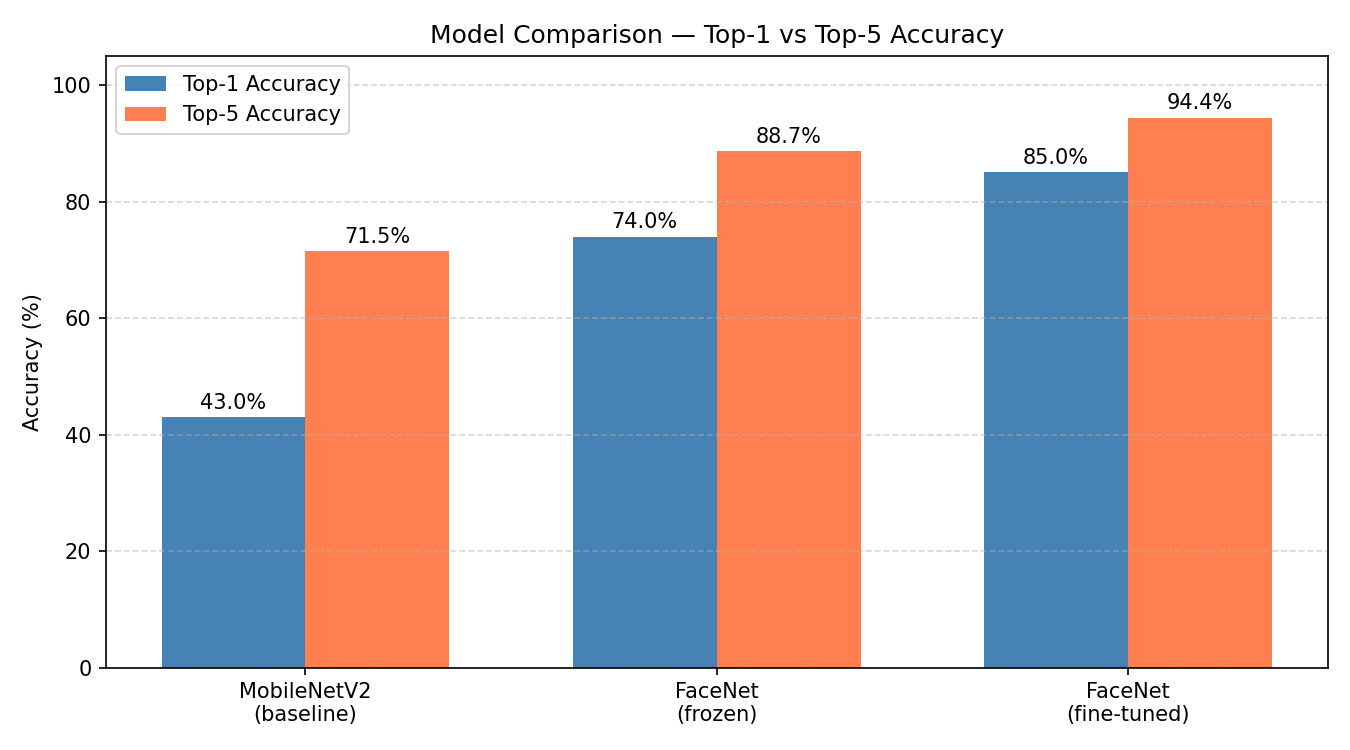

In [1]:
import matplotlib.pyplot as plt
import numpy as np

models    = ['MobileNetV2\n(baseline)', 'FaceNet\n(frozen)', 'FaceNet\n(fine-tuned)']
top1      = [results_mobilenet[1]*100, results_facenet[1]*100, results_finetuned[1]*100]
top5      = [results_mobilenet[2]*100, results_facenet[2]*100, results_finetuned[2]*100]

x     = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, top1, width, label='Top-1 Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, top5, width, label='Top-5 Accuracy', color='coral')

for bar in bars1 + bars2:
    ax.annotate(
        f'{bar.get_height():.1f}%',
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 4), textcoords='offset points',
        ha='center', fontsize=10
    )

ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Comparison — Top-1 vs Top-5 Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 105)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'model_comparison.png', dpi=150)
plt.show()

## Load Saved Model

In [ ]:
# ── Load saved fine-tuned model (no need to retrain) ───────────────
from keras_facenet import FaceNet
from tensorflow.keras import layers, models

# Step 1 — Rebuild exact same architecture used during training
embedder      = FaceNet()
facenet_base  = embedder.model
facenet_base.trainable = True
for layer in facenet_base.layers[:-30]:
    layer.trainable = False

inputs  = tf.keras.Input(shape=(160, 160, 3))
x       = facenet_base(inputs, training=False)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

facenet_model = models.Model(inputs, outputs)

# Step 2 — Load weights only (avoids Keras version mismatch errors)
facenet_model.load_weights(
    '/content/drive/MyDrive/capstone_facerec/facenet_finetuned_best.keras'
)
print('Fine-tuned model loaded ✅')

Fine-tuned model loaded ✅


In [ ]:
# Get class names from directory directly
import os

class_names = sorted(os.listdir(TEST_DIR))
print(f"Total classes : {len(class_names)}")
print(f"Sample classes: {class_names[:5]}")

Total classes : 100
Sample classes: ['ANR', 'AamairKhan', 'Aarthi', 'AkshayKumar', 'Ali']


## Predictions on Test Set

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = facenet_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(f"Total test samples : {len(y_true)}")
print(f"Total classes      : {len(class_names)}")

Total test samples : 3651
Total classes      : 100


## Evaluation & Visualisation

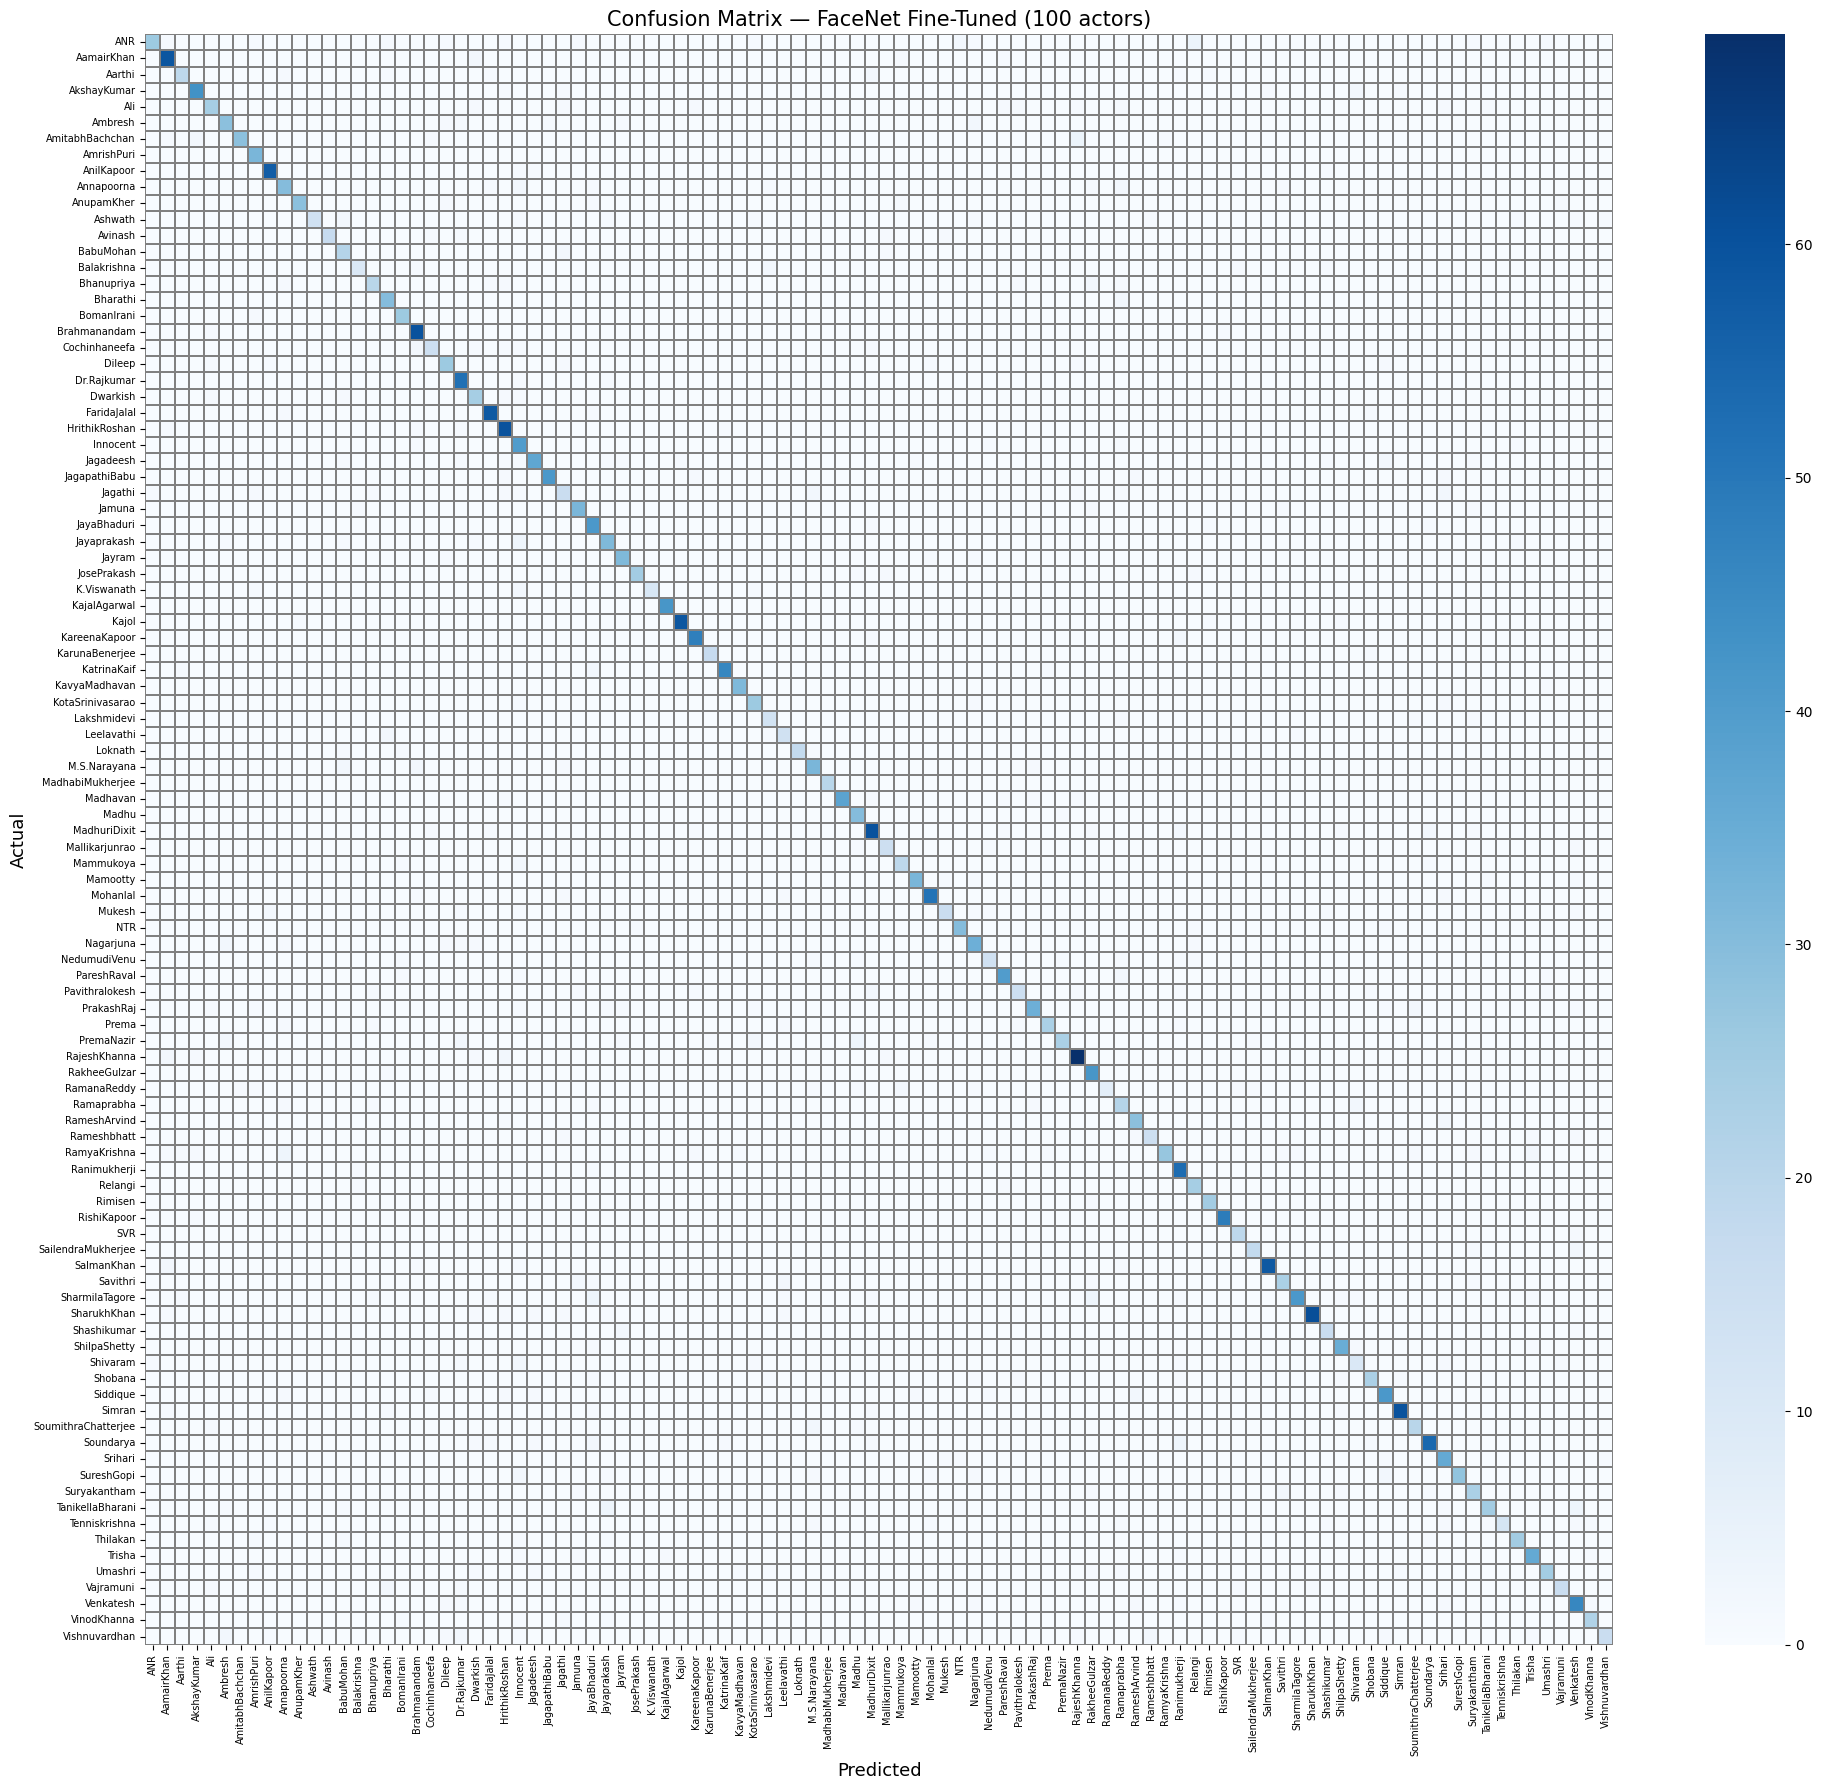

Saved to Drive ✅


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20, 18))
sns.heatmap(
    cm,
    xticklabels=class_names,
    yticklabels=class_names,
    cmap='Blues',
    linewidths=0.3,
    linecolor='gray'
)
plt.xlabel('Predicted', fontsize=13)
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix — FaceNet Fine-Tuned (100 actors)', fontsize=15)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'confusion_matrix.png', dpi=150)
plt.show()
print("Saved to Drive ✅")

In [ ]:
from sklearn.metrics import classification_report

# Full classification report
report = classification_report(
    y_true, y_pred,
    target_names=class_names,
    output_dict=True
)

# Top 5 best performing actors
print("Top 5 best recognized actors:")
actor_scores = {k: v['f1-score'] for k, v in report.items() if k in class_names}
for actor, score in sorted(actor_scores.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {actor:<25} F1: {score:.3f}")

# Bottom 5 worst performing actors
print("\nBottom 5 hardest actors to recognize:")
for actor, score in sorted(actor_scores.items(), key=lambda x: x[1])[:5]:
    print(f"  {actor:<25} F1: {score:.3f}")

# Overall stats
print(f"\nOverall accuracy  : {report['accuracy']*100:.2f}%")
print(f"Macro avg F1      : {report['macro avg']['f1-score']:.3f}")
print(f"Weighted avg F1   : {report['weighted avg']['f1-score']:.3f}")

Top 5 best recognized actors:
  MadhabiMukherjee          F1: 1.000
  KajalAgarwal              F1: 0.988
  RishiKapoor               F1: 0.980
  Kajol                     F1: 0.967
  KavyaMadhavan             F1: 0.954

Bottom 5 hardest actors to recognize:
  Shivaram                  F1: 0.588
  Jagathi                   F1: 0.604
  RamanaReddy               F1: 0.609
  Ramaprabha                F1: 0.667
  Vishnuvardhan             F1: 0.681

Overall accuracy  : 85.05%
Macro avg F1      : 0.834
Weighted avg F1   : 0.850


## Embedding Model & Reference Database

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from PIL import Image
import os

# Extract embedding layer (output before the final Dense/softmax)
embedding_model = tf.keras.Model(
    inputs=facenet_model.input,
    outputs=facenet_model.layers[-3].output  # 512-d FaceNet embedding
)
print(f"Embedding model output shape: {embedding_model.output_shape}")

Embedding model output shape: (None, 512)


In [ ]:
from tqdm import tqdm

reference_embeddings = {}
failed_actors = []

for actor in tqdm(class_names, desc="Building reference DB"):
    actor_dir = os.path.join(TEST_DIR, actor)
    img_files = [f for f in os.listdir(actor_dir)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:10]  # max 10 per actor

    embeds = []
    for img_file in img_files:
        try:
            img = Image.open(os.path.join(actor_dir, img_file)).resize((160, 160))
            arr = np.array(img) / 255.0
            arr = np.expand_dims(arr, axis=0)
            embed = embedding_model.predict(arr, verbose=0)[0]
            embeds.append(embed)
        except Exception as e:
            continue

    if embeds:
        # Average all embeddings for this actor = more robust reference
        reference_embeddings[actor] = np.mean(embeds, axis=0)
    else:
        failed_actors.append(actor)

print(f"\nReference DB built ✅")
print(f"Actors in DB  : {len(reference_embeddings)}")
print(f"Failed actors : {failed_actors if failed_actors else 'None'}")

Building reference DB: 100%|██████████| 100/100 [01:56<00:00,  1.17s/it]


Reference DB built ✅
Actors in DB  : 100
Failed actors : None


## Gradio Demo

In [ ]:
# ── Gradio Demo with Cosine Similarity ───────────────────────────────
import gradio as gr
import numpy as np
from mtcnn import MTCNN
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import os

# ── Safety checks ─────────────────────────────────────────────────────
if 'facenet_model' not in dir():
    raise RuntimeError("❌ facenet_model not found. Run the 'Load Saved Model' cell first.")
if 'class_names' not in dir():
    raise RuntimeError("❌ class_names not found. Run the 'Get class names' cell first.")
if not os.path.exists(TEST_DIR):
    raise RuntimeError(f"❌ TEST_DIR not found: {TEST_DIR}\nRun the 'Load Dataset from Google Drive' cell first.")

# ── Build embedding model if not already built ───────────────────────
if 'embedding_model' not in dir():
    embedding_model = tf.keras.Model(
        inputs=facenet_model.input,
        outputs=facenet_model.layers[-3].output
    )
    print(f"Embedding model ready ✅  output shape: {embedding_model.output_shape}")

# ── Build reference database if not already built ────────────────────
if 'reference_embeddings' not in dir() or len(reference_embeddings) == 0:
    reference_embeddings = {}
    for actor in tqdm(class_names, desc="Building reference DB"):
        actor_dir = os.path.join(TEST_DIR, actor)
        if not os.path.exists(actor_dir):
            continue
        img_files = [f for f in os.listdir(actor_dir)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:10]
        embeds = []
        for img_file in img_files:
            try:
                img = Image.open(os.path.join(actor_dir, img_file)).resize((160, 160))
                arr = np.expand_dims(np.array(img) / 255.0, axis=0)
                embeds.append(embedding_model.predict(arr, verbose=0)[0])
            except Exception:
                continue
        if embeds:
            reference_embeddings[actor] = np.mean(embeds, axis=0)
    print(f"Reference DB built ✅  ({len(reference_embeddings)} actors)")

if len(reference_embeddings) == 0:
    raise RuntimeError("❌ Reference DB is empty — no images found in TEST_DIR. Check that mtcnn_splits was extracted correctly.")

# ── MTCNN detector ────────────────────────────────────────────────────
detector = MTCNN()

def predict_actor(image):
    detections = detector.detect_faces(image)
    if not detections:
        return "❌ No face detected. Try a clearer or more frontal photo.", {}

    best       = max(detections, key=lambda x: x['confidence'])
    x, y, w, h = best['box']

    margin = int(0.2 * max(w, h))
    x1 = max(0, x - margin)
    y1 = max(0, y - margin)
    x2 = min(image.shape[1], x + w + margin)
    y2 = min(image.shape[0], y + h + margin)

    face_crop = image[y1:y2, x1:x2]
    if face_crop.size == 0:
        return "❌ Face crop failed. Please try another photo.", {}

    img       = Image.fromarray(face_crop).resize((160, 160))
    img_array = np.expand_dims(np.array(img) / 255.0, axis=0)

    query_embed = embedding_model.predict(img_array, verbose=0)[0]

    scores = {
        actor: float(cosine_similarity([query_embed], [ref_embed])[0][0])
        for actor, ref_embed in reference_embeddings.items()
    }

    top5 = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:5]
    if not top5:
        return "❌ Could not compute similarity scores.", {}

    top_name  = top5[0][0]
    top_score = top5[0][1]
    result    = dict(top5)

    if top_score >= 0.6:
        verdict = f"✅ Identified: {top_name} ({top_score:.2f} similarity)"
    elif top_score >= 0.4:
        verdict = f"🤔 Possibly: {top_name} ({top_score:.2f} similarity)"
    else:
        verdict = f"❓ Unknown or low confidence ({top_score:.2f} similarity)"

    return verdict, result

# ── Launch Gradio UI ──────────────────────────────────────────────────
demo = gr.Interface(
    fn=predict_actor,
    inputs=gr.Image(type='numpy', label='Upload a face photo'),
    outputs=[
        gr.Textbox(label='Prediction'),
        gr.Label(num_top_classes=5, label='Top 5 matches (cosine similarity)')
    ],
    title='Indian Face Recognition System',
    description='Upload a photo of an Indian actor. MTCNN detects the face → FaceNet extracts embedding → Cosine similarity finds the best match.',
    examples=[],
    theme=gr.themes.Soft()
)

demo.launch(share=True, debug=True)